# Ricochet — notation des articles en étoiles

**Objectif** : produire une note en étoiles (1–5) pour chaque article à partir des
clics, puis s'en servir comme notes explicites pour un modèle de filtrage
collaboratif **SVD (bibliothèque Surprise)**.

Démarche :

1. constater qu'aucune note n'existe dans les données ;
2. construire les étoiles depuis l'historique des clics ;
3. attacher ces étoiles aux couples (lecteur, article) — le jeu de notes ;
4. entraîner un SVD avec Surprise sur ce jeu ;
5. évaluer sur **quatre critères**, pas un seul ;
6. conclure sur ce que les étoiles apportent réellement.

> Prérequis : données complètes dans `data/news-portal-user/clicks/`
> (décompresser `clicks.zip`), et artefacts générés par
> `python -m src.prepare_model --data-dir data/news-portal-user --out-dir models`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')

DATA = Path('..') / 'data' / 'news-portal-user'
MODELS = Path('..') / 'models'

## 1. Le problème : les données ne contiennent aucune note

Surprise, comme tout modèle de prédiction de notes, attend des triplets
`(utilisateur, item, note)`. Regardons ce que fournit réellement le jeu Globo.

In [2]:
from src.prepare_model import load_clicks

clicks = load_clicks(DATA)
print(f'{len(clicks):,} clics')
print('colonnes disponibles :', list(clicks.columns))

articles = pd.read_csv(DATA / 'articles_metadata.csv')
print('colonnes des articles :', list(articles.columns))

[clicks] 1 fichier(s) vide(s) ignoré(s) : clicks_hour_100.csv
2,988,181 clics
colonnes disponibles : ['user_id', 'click_article_id', 'click_timestamp', 'click_region']
colonnes des articles : ['article_id', 'category_id', 'created_at_ts', 'publisher_id', 'words_count']


Aucune colonne de note, d'avis ou d'appréciation. Le signal est **implicite** : on
sait seulement qu'un lecteur a ouvert un article.

Deux voies existent pour en dériver une note :

| Voie | Principe | Limite |
|---|---|---|
| Intensité par couple | nombre de fois qu'un lecteur ouvre le **même** article | 98,9 % des couples restent à 1 clic |
| **Popularité de l'article** | nombre total de clics reçus par l'article | la note ne dépend pas du lecteur |

C'est la seconde qui est développée ici : elle utilise **tout** l'historique et
produit une échelle 1–5 exploitable. Sa conséquence — la note est une propriété de
l'article, pas du lecteur — est mesurée en section 5.

## 2. Construire les étoiles

### 2.1 Compter les clics par article

In [3]:
counts = clicks['click_article_id'].value_counts()

print(f'articles ayant reçu au moins un clic : {len(counts):,} sur {len(articles):,}')
print()
print(counts.describe(percentiles=[.5, .75, .9, .99]).round(1).to_string())

articles ayant reçu au moins un clic : 46,033 sur 364,047

count    46033.0
mean        64.9
std        629.3
min          1.0
50%          1.0
75%          6.0
90%         39.0
99%       1203.4
max      37213.0


### 2.2 Pourquoi pas des quantiles

Le réflexe serait de découper en cinq classes d'effectifs égaux. Cela ne fonctionne
pas ici : la distribution est en loi de puissance et sa **médiane vaut 1 clic**.

In [4]:
bornes = counts.quantile([0, .2, .4, .6, .8, 1.0]).astype(int).tolist()
print('bornes des quintiles :', bornes)
print('bornes distinctes ?  ', len(set(bornes)) == len(bornes))
print()
print('nombre d\'articles par nombre de clics (10 premiers) :')
print(counts.value_counts().sort_index().head(10).to_string())

bornes des quintiles : [1, 1, 1, 2, 11, 37213]
bornes distinctes ?   False

nombre d'articles par nombre de clics (10 premiers) :
count
1     24811
2      4682
3      2129
4      1315
5       990
6       746
7       621
8       504
9       476
10      384


Quatre bornes sur cinq tombent sur la même valeur : plus de la moitié des articles
ont exactement 1 clic, on ne peut donc pas les répartir en classes égales. Une
notation par quantiles collerait la même note à des articles très différents et
laisserait les classes hautes quasi vides.

### 2.3 Échelle logarithmique

Le nombre de clics couvre plus de quatre ordres de grandeur (de 1 à ~37 000). Une
échelle logarithmique répartit donc les articles de façon lisible, chaque étoile
correspondant à un facteur 10 :

| Note | Clics |
|---|---|
| ★ | 1 – 9 |
| ★★ | 10 – 99 |
| ★★★ | 100 – 999 |
| ★★★★ | 1 000 – 9 999 |
| ★★★★★ | 10 000 et plus |

C'est exactement ce que calcule `build_article_stars` dans `src/prepare_model.py`.

In [5]:
from src.prepare_model import build_article_stars

stars = build_article_stars(clicks, MODELS)
article_clicks = np.load(MODELS / 'article_clicks.npy')

table = pd.DataFrame({
    'articles': [int((stars == s).sum()) for s in range(1, 6)],
    'clics min': [int(article_clicks[stars == s].min()) for s in range(1, 6)],
    'clics max': [int(article_clicks[stars == s].max()) for s in range(1, 6)],
}, index=[f'{s}★' for s in range(1, 6)])
table

[article_stars] 46,033 articles notés — 1★:36,274 · 2★:7,235 · 3★:1,988 · 4★:497 · 5★:39
[article_stars] artefacts ~1.8 Mo


,articles,clics min,clics max
1★,36274,1,9
2★,7235,10,99
3★,1988,100,999
4★,497,1000,9993
5★,39,10061,37213


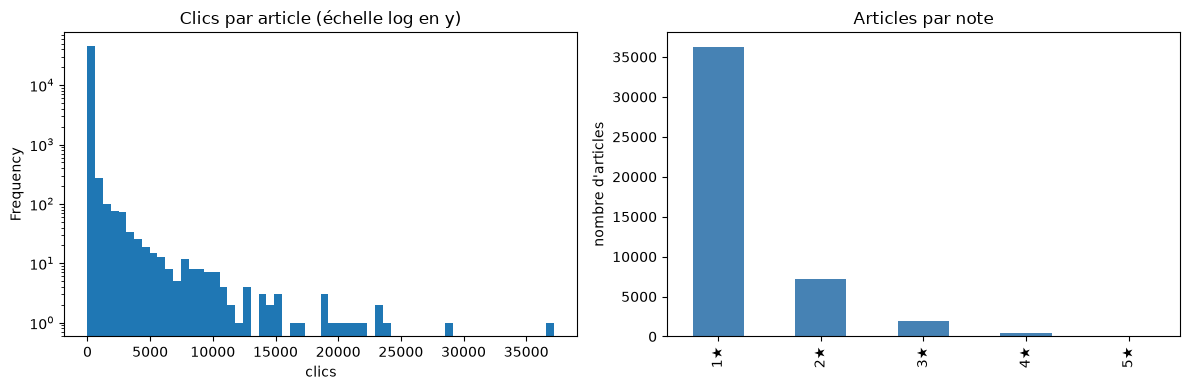

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts.plot.hist(bins=60, logy=True, ax=axes[0])
axes[0].set_title('Clics par article (échelle log en y)')
axes[0].set_xlabel('clics')

table['articles'].plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('Articles par note')
axes[1].set_ylabel('nombre d\'articles')
plt.tight_layout()

### 2.4 Le poids de l'artefact

Tout l'intérêt de la démarche : l'historique complet (des dizaines de Mo de données
utilisateur) est **distillé en un octet par article**. C'est ce qui permet de servir
une note sans embarquer l'historique dans le service de recommandation.

In [7]:
poids = {
    'article_stars.npy (1 octet/article)': (MODELS / 'article_stars.npy').stat().st_size,
    'article_clicks.npy (4 octets/article)': (MODELS / 'article_clicks.npy').stat().st_size,
    'user_clicks.pkl (historique complet)': (MODELS / 'user_clicks.pkl').stat().st_size,
}
for nom, taille in poids.items():
    print(f'{nom:42s} {taille / 1e6:8.2f} Mo')

article_stars.npy (1 octet/article)            0.36 Mo
article_clicks.npy (4 octets/article)          1.46 Mo
user_clicks.pkl (historique complet)          33.17 Mo


## 3. Le jeu de notes pour Surprise

Les étoiles se rattachent maintenant à chaque couple **(lecteur, article lu)** : si
un lecteur a ouvert un article noté 4★, le triplet devient `(lecteur, article, 4)`.

C'est la forme qu'attend Surprise.

In [8]:
from src.collaborative_surprise import build_ratings_from_stars

ratings = build_ratings_from_stars(clicks, MODELS)
ratings.head()

[notes] 2,950,710 couples notés à partir des étoiles — 1★:66,488 · 2★:228,737 · 3★:566,266 · 4★:1,473,198 · 5★:616,021


,user_id,article_id,rating
0,0,157541,3
1,0,68866,4
2,1,235840,3
3,1,96663,4
4,2,119592,4


In [9]:
spread = ratings['rating'].value_counts().sort_index()
pd.DataFrame({'couples notés': spread,
              'part': (spread / len(ratings) * 100).round(1).astype(str) + ' %'})

,couples notés,part
rating,,
1,66488,2.3 %
2,228737,7.8 %
3,566266,19.2 %
4,1473198,49.9 %
5,616021,20.9 %


**Lecture importante.** La distribution est très déséquilibrée **vers le haut** :
la majorité des couples reçoivent 4★ ou 5★, et seuls ~2 % obtiennent 1★.

Ce n'est pas une anomalie, c'est mécanique : les clics se concentrent sur les
articles populaires, or ce sont précisément eux qui ont beaucoup d'étoiles. Un
lecteur tiré au hasard lit surtout des articles très lus.

Conséquence à retenir pour la suite : la note apporte peu de contraste entre les
articles qu'un lecteur donné a ouverts.

## 4. Entraîner le SVD avec Surprise

Deux points de conception importants.

**Surprise n'est utilisée qu'ici, hors-ligne.** On sérialise ensuite les *facteurs
appris* (`pu`, `qi`, les biais, la moyenne globale), et l'inférence rejoue le calcul
de Surprise en numpy :

$$\hat{r}_{ui} = \mu + b_u + b_i + p_u \cdot q_i$$

Ni `Recommender`, ni l'Azure Function, ni les Spaces n'importent Surprise — ce qui
préserve la contrainte « inférence en numpy seul ».

**L'entraînement prend quelques minutes** sur 2,95 M de notes. Réduisez
`ECHANTILLON` pour un essai rapide.

In [10]:
from src.collaborative_surprise import train_svd, save_artifacts

ECHANTILLON = None          # ex. 300_000 pour un essai rapide
jeu = ratings if ECHANTILLON is None else ratings.sample(ECHANTILLON, random_state=42)
print(f'entraînement sur {len(jeu):,} notes…')

algo, trainset = train_svd(jeu, n_factors=50, n_epochs=20)
save_artifacts(algo, trainset, MODELS)

entraînement sur 2,950,710 notes…


[svd] 322,897 users x 46,033 items, 50 facteurs, ~78.6 Mo d'artefacts


### Vérification : le score numpy reproduit-il Surprise ?

Si les facteurs sont correctement sérialisés, le score reconstruit à la main doit
égaler `algo.predict()`. C'est la garantie que l'inférence sans Surprise est fidèle.

In [11]:
import pickle

pu = np.load(MODELS / 'svd_user_factors.npy')
qi = np.load(MODELS / 'svd_item_factors.npy')
bu = np.load(MODELS / 'svd_user_bias.npy')
bi = np.load(MODELS / 'svd_item_bias.npy')
mu = float(np.load(MODELS / 'svd_global_mean.npy')[0])
with open(MODELS / 'svd_user_index.pkl', 'rb') as f:
    user_index = pickle.load(f)
item_ids = np.load(MODELS / 'svd_item_ids.npy')

raw_u = next(iter(user_index))
u, i = user_index[raw_u], 0
score_numpy = mu + bu[u] + bi[i] + pu[u] @ qi[i]
score_surprise = algo.predict(raw_u, int(item_ids[i])).est

print(f'numpy    : {score_numpy:.6f}')
print(f'surprise : {score_surprise:.6f}')
print(f'écart    : {abs(score_numpy - score_surprise):.2e}')
print('(Surprise borne la note à l\'échelle déclarée : un écart apparaît si le score sort de l\'intervalle)')

numpy    : 3.094622
surprise : 3.094622
écart    : 1.80e-07
(Surprise borne la note à l'échelle déclarée : un écart apparaît si le score sort de l'intervalle)


## 5. Évaluation — quatre critères, pas un seul

### Protocole

*Leave-last-out* : pour chaque lecteur ayant assez d'historique, on masque son
**dernier clic** et on regarde s'il figure dans le top-N recommandé.

Trois limites à énoncer d'emblée :

- les modèles collaboratifs (ALS et SVD) ont été entraînés **avec** le clic masqué :
  leurs scores sont donc optimistes ;
- avec 300 lecteurs, la résolution de la métrique est 1/300 ≈ 0,0033. Un « 0,0000 »
  signifie « inférieur à 0,003 », pas « exactement zéro » ;
- le hasard pur donnerait 5/364 047 ≈ 1,4·10⁻⁵.

### Pourquoi quatre critères

Le taux de succès seul récompense mécaniquement ce qui ressemble à la popularité.
On y ajoute donc :

| Critère | Ce qu'il mesure | Ce qu'il révèle |
|---|---|---|
| **HR@5 / HR@50** | le clic masqué est-il dans le top-N | précision brute |
| **Couverture** | part du catalogue jamais recommandée | l'éditeur veut-il ne pousser que 40 articles ? |
| **Personnalisation** | différence entre les listes de deux lecteurs | **le modèle personnalise-t-il vraiment** |

In [12]:
import itertools
from src.recommender import Recommender

reco = Recommender(MODELS)
utilisateurs = [u for u, h in reco.user_clicks.items() if len(h) >= 5][:300]
print(f'{len(utilisateurs)} lecteurs évalués | SVD chargé : {reco._has_svd}')

pool = np.flatnonzero(np.load(MODELS / 'article_clicks.npy') > 0)   # articles cliqués


def content_restreint(u, n):
    """Content-based limité aux articles déjà cliqués (même vivier que l'ALS)."""
    vus = reco.user_clicks.get(u, np.array([], dtype=np.int64))
    profil = reco.embeddings[vus].mean(axis=0)
    norme = np.linalg.norm(profil)
    if norme == 0:
        return []
    scores = reco.embeddings[pool] @ (profil / norme)
    scores[np.isin(pool, vus)] = -np.inf
    k = min(n, scores.size)
    idx = np.argpartition(-scores, k - 1)[:k]
    return pool[idx[np.argsort(-scores[idx])]].tolist()


def mesurer(fonction, n):
    succes, listes = 0, []
    for u in utilisateurs:
        articles_lus = reco.user_clicks[u]
        cible = int(articles_lus[-1])
        reco.user_clicks[u] = articles_lus[:-1]        # on masque le dernier clic
        try:
            recommandations = fonction(u, n)
        finally:
            reco.user_clicks[u] = articles_lus         # on restaure
        succes += cible in recommandations
        listes.append(set(recommandations[:5]))

    couverture = len({a for l in listes for a in l}) / reco.n_articles
    paires = list(itertools.islice(itertools.combinations(range(len(listes)), 2), 3000))
    recouvrement = np.mean([len(listes[i] & listes[j]) / 5 for i, j in paires])
    return succes / len(utilisateurs), couverture, 1 - recouvrement


methodes = {
    'ALS (implicit)':      lambda u, n: reco.recommend(u, n=n, method='collab'),
    'SVD étoiles (Surprise)': lambda u, n: reco.recommend(u, n=n, method='svd'),
    'Content (catalogue)': lambda u, n: reco.recommend(u, n=n, method='content'),
    'Content (cliqués)':   content_restreint,
    'Popularité (aucun modèle)': lambda u, n: reco._popularity_fallback(u, n),
}

lignes = []
for nom, fonction in methodes.items():
    hr5, couverture, personnalisation = mesurer(fonction, 5)
    hr50, _, _ = mesurer(fonction, 50)
    lignes.append({'méthode': nom, 'HR@5': round(hr5, 4), 'HR@50': round(hr50, 4),
                   'couverture %': round(couverture * 100, 3),
                   'personnalisation %': round(personnalisation * 100, 1)})

resultats = pd.DataFrame(lignes).set_index('méthode')
resultats

300 lecteurs évalués | SVD chargé : True


,HR@5,HR@50,couverture %,personnalisation %
méthode,,,,
ALS (implicit),0.2300,0.3733,0.044,94.6
SVD étoiles (Surprise),0.0000,0.1467,0.006,22.6
Content (catalogue),0.0000,0.0067,0.318,99.5
Content (cliqués),0.0033,0.0133,0.254,99.1
Popularité (aucun modèle),0.0200,0.1733,0.005,24.4


### Lecture des résultats

**Le SVD sur les étoiles ne personnalise pas.** C'est le point décisif : sa
personnalisation est **inférieure à celle de la popularité**, un « modèle » qui sert
la même liste à tout le monde. Autrement dit, il reproduit la popularité — et plus
grossièrement, puisque les étoiles écrasent le nombre exact de clics en cinq classes
(39 articles partagent 5★, leur ordre interne n'est que du bruit).

La raison est structurelle : **la note ne dépend que de l'article**. Deux lecteurs
donnent la même note au même article, donc le modèle apprend « quels articles sont
lus », pas « qui lit quoi ». Le biais article `b_i` capte l'essentiel du signal.

Vérifions-le directement : les articles recommandés par le SVD ont-ils tous 5★ ?

In [13]:
u = utilisateurs[0]
for methode in ('collab', 'svd'):
    recs = reco.recommend(u, n=5, method=methode)
    print(f'{methode:8s} ->', [(a, f'{int(stars[a])}★') for a in recs])

collab   -> [(293114, '4★'), (284985, '4★'), (272218, '4★'), (160940, '4★'), (124749, '5★')]
svd      -> [(272143, '5★'), (199198, '5★'), (272660, '5★'), (199197, '5★'), (160417, '5★')]


## 6. Conclusion

**Les étoiles comme artefact : utiles.** 1,8 Mo issus de 3 millions de clics, servis
sans embarquer l'historique. Trois usages légitimes :

- afficher « ★★★★ » à côté d'un article dans l'application ;
- trier le catalogue par popularité lisible ;
- départager des ex-æquo dans un classement.

**Les étoiles comme notes pour un SVD : non.** Le verdict ne repose pas sur une
préférence mais sur deux mesures :

- taux de succès inférieur à la popularité triviale ;
- personnalisation inférieure à la popularité triviale.

Un modèle qui coûte 78 Mo de facteurs et n'égale pas un classement par popularité
n'a pas de justification.

**Ce que cette étude établit pour l'architecture.** La note d'un article et la
préférence d'un lecteur sont deux objets différents. Une note d'article, aussi bien
construite soit-elle, ne peut pas personnaliser — il faut un signal qui dépende du
couple (lecteur, article) : le contenu lu (embeddings) ou la co-lecture (ALS).

Pour aller plus loin avec Surprise sur ce jeu, il faudrait un **échantillonnage
négatif** (articles non lus notés 0), ce qui transforme la tâche en classement.
`src/collaborative_surprise.py` le propose via `--negatives` : avec 4 négatifs par
positif, HR@5 passe de 0,0000 à 0,0567 — toujours en dessous de l'ALS (0,2300), qui
utilise, lui, la totalité des cases vides comme négatifs pondérés.

## 7. Reproduire hors du notebook

```bash
# 1. étoiles + tous les autres artefacts
python -m src.prepare_model --data-dir data/news-portal-user --out-dir models

# 2. SVD Surprise sur les étoiles
python -m src.collaborative_surprise --data-dir data/news-portal-user \
    --out-dir models --rating stars

# 3. variante avec échantillonnage négatif (notes binaires)
python -m src.collaborative_surprise --data-dir data/news-portal-user \
    --out-dir models --rating clicks --negatives 4
```